In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


# 1. Business Understanding

Airbnb has transformed the short-term rental market by allowing hosts to rent their properties to travelers worldwide. However, listing prices vary considerably due to several factors such as location, room type, availability, host characteristics, and customer reviews. Understanding these factors is essential for developing effective pricing strategies and improving market competitiveness.

The primary objective of this study is to identify the factors influencing Airbnb listing prices in New York City using Ordinary Least Squares (OLS) Regression. Unlike black-box machine learning models, OLS provides interpretable coefficients, hypothesis testing, confidence intervals, and statistical significance, making it suitable for explaining the relationship between property characteristics and listing prices.

# 2. Problem Statement

Airbnb listing prices exhibit substantial variation across different neighbourhoods and property types. Hosts often face challenges in determining competitive prices, while researchers require interpretable statistical models to identify the factors significantly affecting listing prices.

This study aims to analyze the Airbnb dataset, identify the major determinants of listing prices, and develop an interpretable OLS Regression model that explains the relationship between listing characteristics and price.

# 3. Research Gap

Although numerous studies have explored Airbnb price prediction using machine learning algorithms such as Random Forest, Gradient Boosting, and XGBoost, several limitations remain.

Most existing studies prioritize prediction accuracy over model interpretability.
Many studies do not perform comprehensive Exploratory Data Analysis (EDA) before model development.
Limited attention is given to handling missing values, outliers, and categorical variables through systematic preprocessing.
Several regression studies fail to validate key OLS assumptions, including linearity, multicollinearity, homoscedasticity, normality of residuals, and independence of errors.
Existing research often focuses on prediction rather than identifying statistically significant factors that influence Airbnb prices.

Therefore, there is a need for a comprehensive and interpretable statistical framework that combines rigorous data preprocessing, feature engineering, exploratory data analysis, and OLS regression to identify the key drivers of Airbnb listing prices.

# 4. Objectives

The objectives of this study are:  

To perform comprehensive Exploratory Data Analysis (EDA) on the Airbnb dataset.  
To assess data quality by identifying missing values, duplicates, invalid observations, and outliers.  
To preprocess the dataset by handling missing values, removing unnecessary variables, and preparing features for regression analysis.  
To engineer meaningful features that improve model interpretability.  
To develop an Ordinary Least Squares (OLS) Regression model for predicting Airbnb listing prices.  
To validate all major assumptions of OLS regression.  
To identify statistically significant variables influencing Airbnb prices.  
To provide business insights and pricing recommendations based on statistical evidence. 

# 5. Dataset Description

The dataset contains Airbnb listings in New York City, USA.  

Number of Observations: 48,895  

Number of Features: 16  

The dataset includes information related to:  

Listing information  
Host information  
Property location  
Room type  
Price  
Customer reviews  
Availability  
Minimum stay requirements  

The dependent variable selected for this study is Price, while the remaining relevant variables are considered as independent variables.  

# 6. Methodology

The study follows the CRISP-DM data science methodology.

Business Understanding  
Data Understanding  
Exploratory Data Analysis  
Data Cleaning  
Feature Engineering  
Data Preprocessing  
OLS Regression Modeling  
Assumption Testing  
Model Evaluation  
Business Insights  
Conclusion

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.shape

(48895, 16)

In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [11]:
df.nunique().sort_values()

room_type                             3
neighbourhood_group                   5
calculated_host_listings_count       47
minimum_nights                      109
neighbourhood                       221
availability_365                    366
number_of_reviews                   394
price                               674
reviews_per_month                   937
last_review                        1764
host_name                         11452
longitude                         14718
latitude                          19048
host_id                           37457
name                              47905
id                                48895
dtype: int64

In [12]:
(df['price']==0).sum()

np.int64(11)

In [13]:
(df['price']<0).sum()

np.int64(0)

In [14]:
(df['minimum_nights']>365).sum()

np.int64(14)

In [15]:
(df['availability_365']>365).sum()

np.int64(0)

# Univariate Analysis — Price (Target Variable)

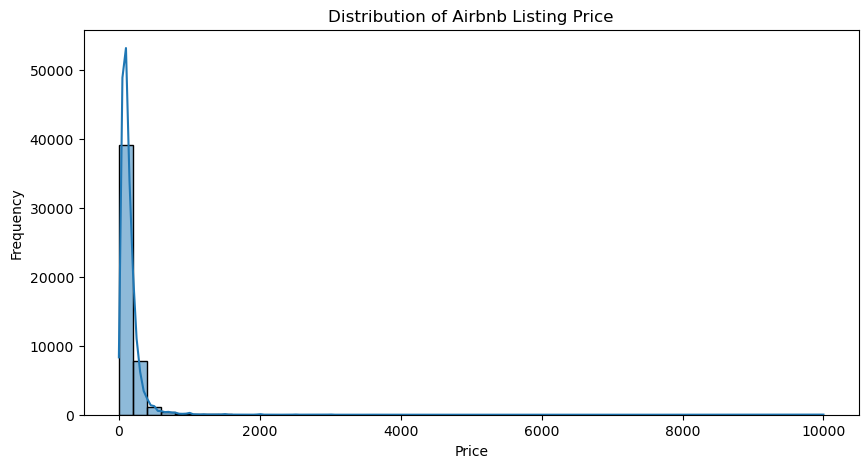

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Airbnb Listing Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

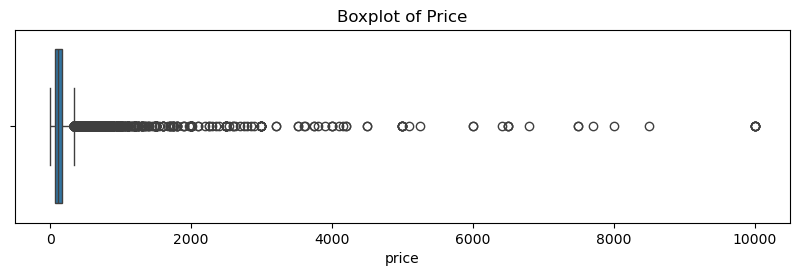

In [17]:
plt.figure(figsize=(10,2.5))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

In [18]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [19]:
print("Skewness :", df['price'].skew())
print("Kurtosis :", df['price'].kurt())

Skewness : 19.118938995046033
Kurtosis : 585.6728788988286


### Report

#### Statistical Summary

Count: 48,895  
Mean: 152.72  
Median: 106  
Standard Deviation: 240.15  
Minimum: 0  
Maximum: 10,000  

#### Interpretation

Mean (152.72) is considerably higher than the median (106), indicating a positively skewed distribution.  
Most listings are concentrated in the lower price range.  
A few luxury listings with very high prices stretch the distribution.  

#### Pattern Identified

Presence of extreme high-value listings.  
At least one listing has price = 0, which requires investigation during data cleaning.

#### Business Insight

The Airbnb market is dominated by affordable listings, while a small number of premium properties significantly increase the average price.  

#### OLS Perspective

Target variable is not normally distributed.  
Log transformation will be evaluated after EDA, not now.  


# Minimum Nights

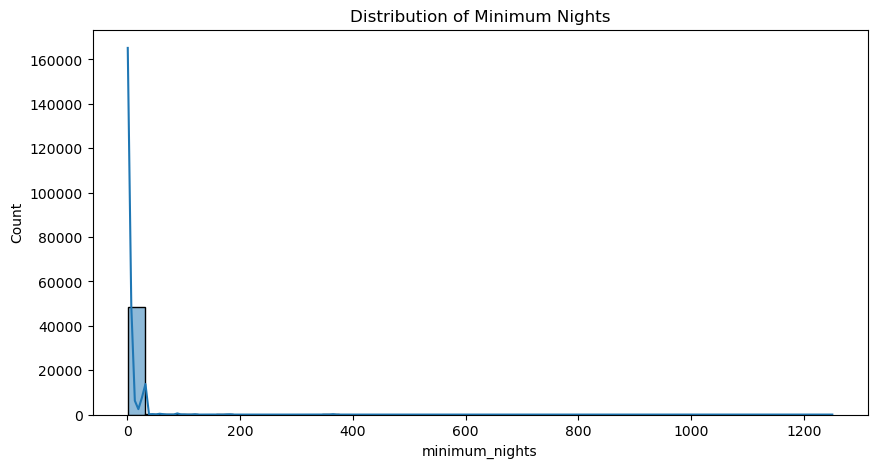

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['minimum_nights'], bins=40, kde=True)
plt.title("Distribution of Minimum Nights")
plt.show()

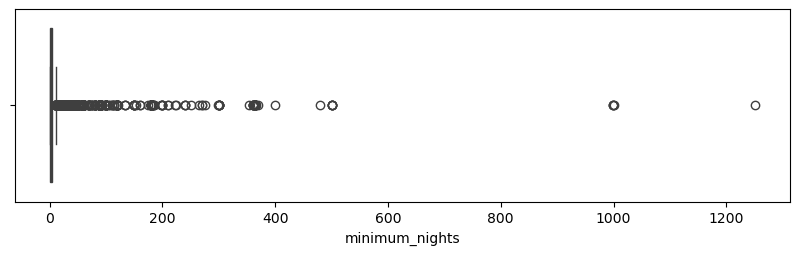

In [21]:
plt.figure(figsize=(10,2.5))
sns.boxplot(x=df['minimum_nights'])
plt.show()

In [22]:
df['minimum_nights'].describe()

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [23]:
print("Skewness :", df['minimum_nights'].skew())
print("Kurtosis :", df['minimum_nights'].kurt())

Skewness : 21.827274529642168
Kurtosis : 854.0716624053883


### Report

#### Statistical Summary

Mean: 7.03  
Median: 3  
Minimum: 1  
Maximum: 1250 

#### Interpretation

The majority of listings require only 1–5 nights.  
A few listings require extremely long minimum stays (up to 1250 nights), creating a highly right-skewed distribution.  

#### Pattern Identified

Most hosts prefer short-term bookings.  
A small number of commercial or long-term rental listings create extreme values.  

#### Business Insight

Short-term rentals dominate the Airbnb market, while long minimum-stay listings represent a niche segment.

#### OLS Perspective

Feature is useful.  
Extreme observations should be investigated during preprocessing.


# Number of Reviews

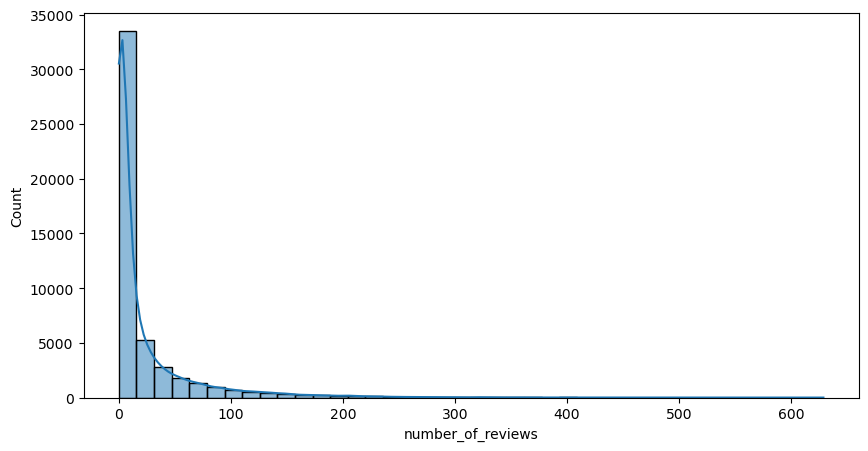

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['number_of_reviews'], bins=40, kde=True)
plt.show()

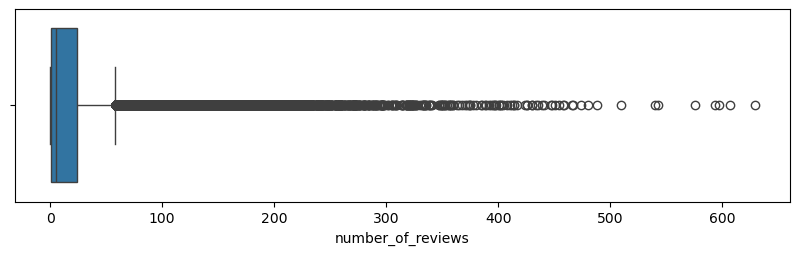

In [25]:
plt.figure(figsize=(10,2.5))
sns.boxplot(x=df['number_of_reviews'])
plt.show()

In [26]:
df['number_of_reviews'].describe()

count    48895.000000
mean        23.274466
std         44.550582
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [27]:
print("Skewness :", df['number_of_reviews'].skew())

Skewness : 3.690634571595388


### Report

#### Statistical Summary

Mean: 23.27  
Median: 5  
Maximum: 629  

#### Interpretation

Most listings receive relatively few reviews, while a limited number of highly popular listings accumulate hundreds of reviews.

#### Business Insight

Listings with higher review counts may indicate greater popularity, trust, and booking frequency.

#### OLS Perspective

Keep this feature because it may significantly influence listing prices.


# Room Type


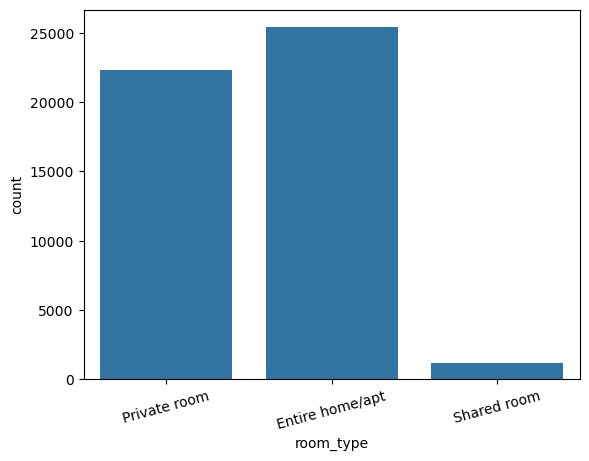

room_type
Entire home/apt    51.97
Private room       45.66
Shared room         2.37
Name: proportion, dtype: float64

In [28]:
sns.countplot(data=df, x='room_type')
plt.xticks(rotation=15)
plt.show()
df['room_type'].value_counts()
round(df['room_type'].value_counts(normalize=True)*100,2)


### Report

#### Interpretation

The majority of listings belong to Entire home/apartment, followed by Private room, while Shared room represents only a small proportion.  

#### Business Insight

Guests generally prefer booking entire properties, reflecting higher demand for privacy and convenience.

#### OLS Perspective

Categorical variable → One-Hot Encoding during preprocessing.


#  Neighbourhood


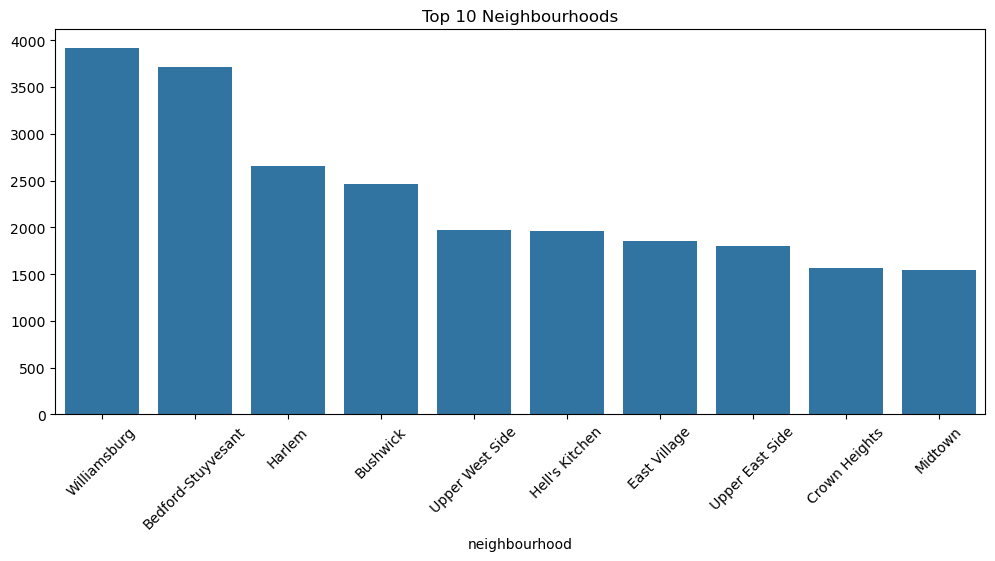

In [29]:
top10 = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top10.index, y=top10.values)
plt.xticks(rotation=45)
plt.title("Top 10 Neighbourhoods")
plt.show()


### Report

#### Interpretation

Only a limited number of neighbourhoods account for a large share of Airbnb listings, while many neighbourhoods have relatively few listings.

#### Business Insight

Neighbourhood-level demand is highly uneven, suggesting that local market conditions strongly influence listing availability and pricing.

#### OLS Perspective

Keep this feature and apply One-Hot Encoding before model development.


## Conclusion of Univariate EDA

price, minimum_nights, number_of_reviews, reviews_per_month, and calculated_host_listings_count are right-skewed and contain potential outliers that should be examined during preprocessing.  
reviews_per_month has 20.56% structural missing values, so no treatment is performed during EDA.  
room_type, neighbourhood_group, and neighbourhood are important categorical variables and should be encoded before OLS regression.  
No feature is dropped during the Univariate EDA stage.  
All cleaning, transformation, feature engineering, and feature selection decisions will be made only after completing the full EDA.   This is the workflow expected in a professional data science project.


# Bivariate Analysis (Target Variable = Price)

#  Price vs Room Type

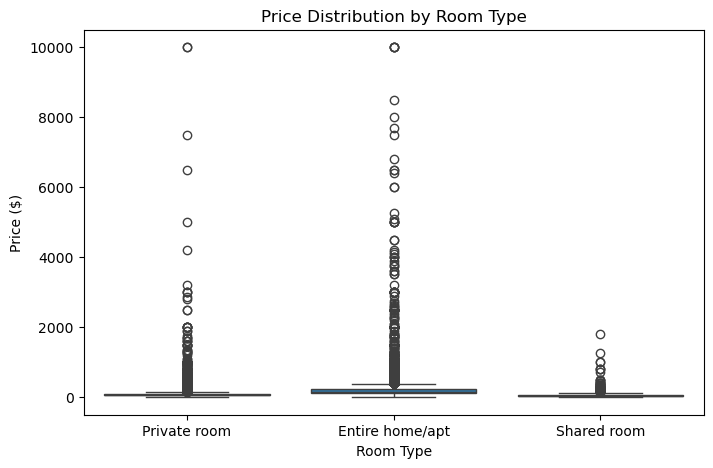

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='room_type',
            y='price')

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()


### Interpretation

Compare the median price across room types.  
Compare the spread (IQR) of prices.  
Identify which room type has the largest number of high-price outliers.

#### Business Insight

Room type directly influences listing price because guests are willing to pay more for greater privacy and exclusive access.

#### OLS Perspective

Categorical predictor.  
Apply One-Hot Encoding before OLS.  
Expected to be an important predictor. 

#### Assessment	Status

Business Relevance	High  
Expected Relationship with Price	Strong  
Encoding Required	Yes  
Keep for OLS	Yes


# Price vs Neighbourhood Group

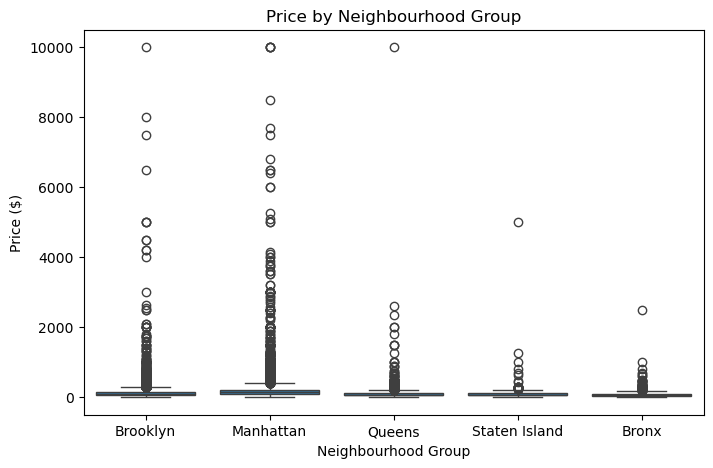

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)

plt.title("Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.show()


### Interpretation

Compare the median price across boroughs.  
Observe variability within each borough.  
Detect premium and budget boroughs.

#### Business Insight

Location is one of the primary drivers of Airbnb pricing because demand, accessibility, and tourist attractions vary across boroughs.

#### OLS Perspective

Strong categorical predictor.  
Encode using One-Hot Encoding.  
Likely to contribute significantly to price prediction.

#### Assessment	Status

Business Relevance	High  
Expected Relationship with Price	Strong  
Encoding Required	Yes  
Keep for OLS	Yes


# Price vs Minimum Nights


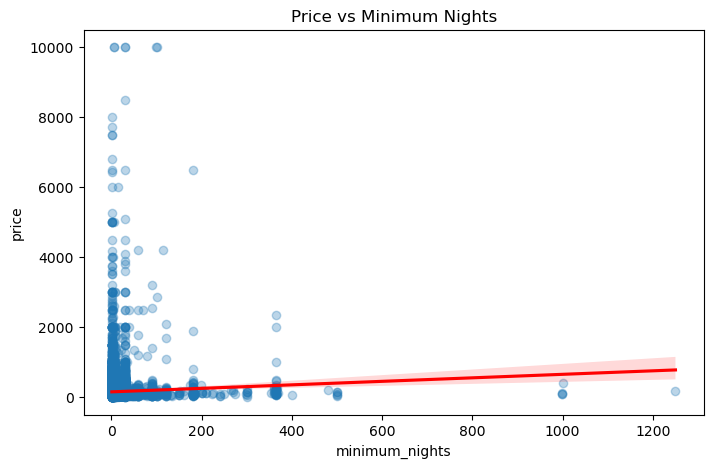

In [32]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='minimum_nights',
    y='price',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Price vs Minimum Nights")
plt.show()


### Interpretation

Observe whether prices tend to increase or decrease as the minimum stay requirement increases.  
Check whether the regression line indicates a positive, negative, or weak relationship.  
Identify any influential outliers.

#### Business Insight

Hosts with longer minimum-stay requirements may target longer bookings rather than higher prices.

#### OLS Perspective

Numerical predictor.  
Linearity will be evaluated through this plot.  
Retain for OLS and confirm significance using p-values.

#### Assessment	Status

Business Relevance	Medium  
Expected Relationship with Price	To be confirmed  
Keep for OLS	Yes


# Price vs Number of Reviews


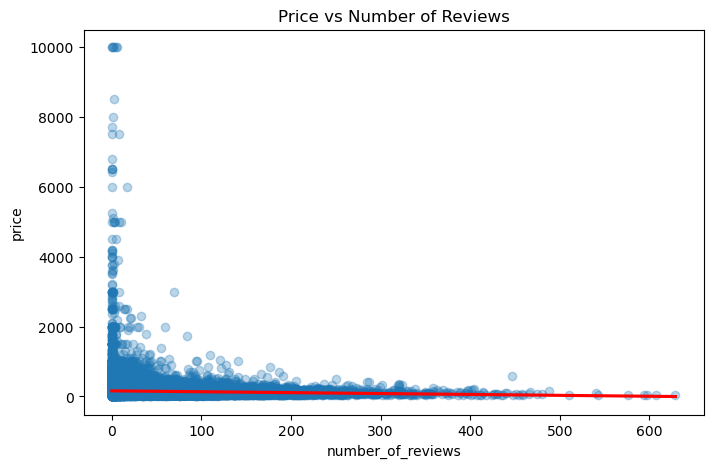

In [33]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='number_of_reviews',
    y='price',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Price vs Number of Reviews")
plt.show()


### Interpretation

Assess whether listings with more reviews tend to have different prices.  
Examine the fitted regression line for trend direction.  
Note any extreme observations. 

#### Business Insight

Review count reflects customer engagement and popularity, which may influence pricing strategies.

#### OLS Perspective

Numerical predictor.  
Retain and evaluate coefficient significance during model fitting.

#### Assessment	Status

Business Relevance-	Medium  
Expected Relationship with Price-	To be confirmend  
Keep for OLS-	Yes


#  Price vs Reviews per Month


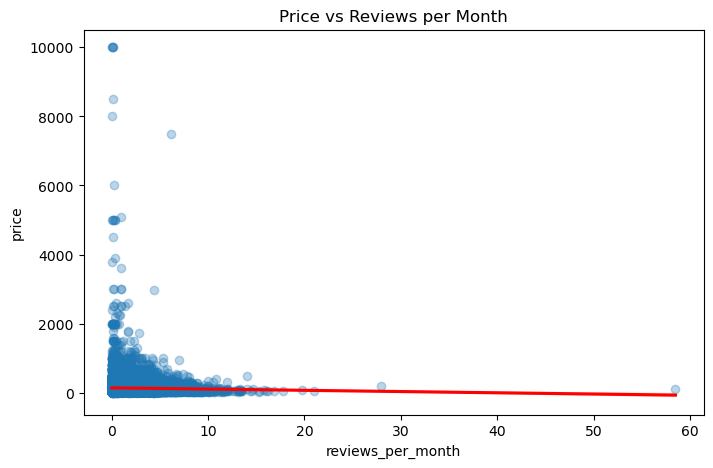

In [34]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='reviews_per_month',
    y='price',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Price vs Reviews per Month")
plt.show()


### Interpretation

Evaluate whether review frequency is associated with listing prices.  
Consider that missing values represent structural missingness (no reviews).  

#### Business Insight

Frequently reviewed listings often indicate higher booking activity and may follow different pricing strategies.

#### OLS Perspective

Handle missing values before model fitting.  
Retain for OLS.  

#### Assessment	Status

Business Relevance-	Medium  
Missing Values	-Yes  
Keep for OLS-	Yes

# Price vs Availability_365


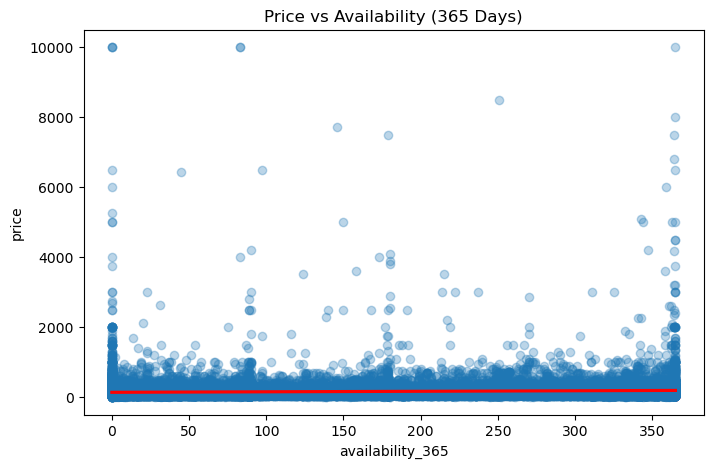

In [35]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='availability_365',
    y='price',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Price vs Availability (365 Days)")
plt.show()


### Interpretation

Examine whether yearly availability is associated with listing prices.  
Evaluate the slope of the fitted regression line.  
Identify any unusual observations.

#### Business Insight

Availability reflects hosting strategy and occupancy patterns, which may indirectly influence pricing.

#### OLS Perspective

Numerical predictor.  
Retain and validate significance during regression.  

#### Assessment	Status

Business Relevance-	Medium  
Expected Relationship with Price-	To be confirmed  
Keep for OLS-	Yes


# Correlation Heatmap

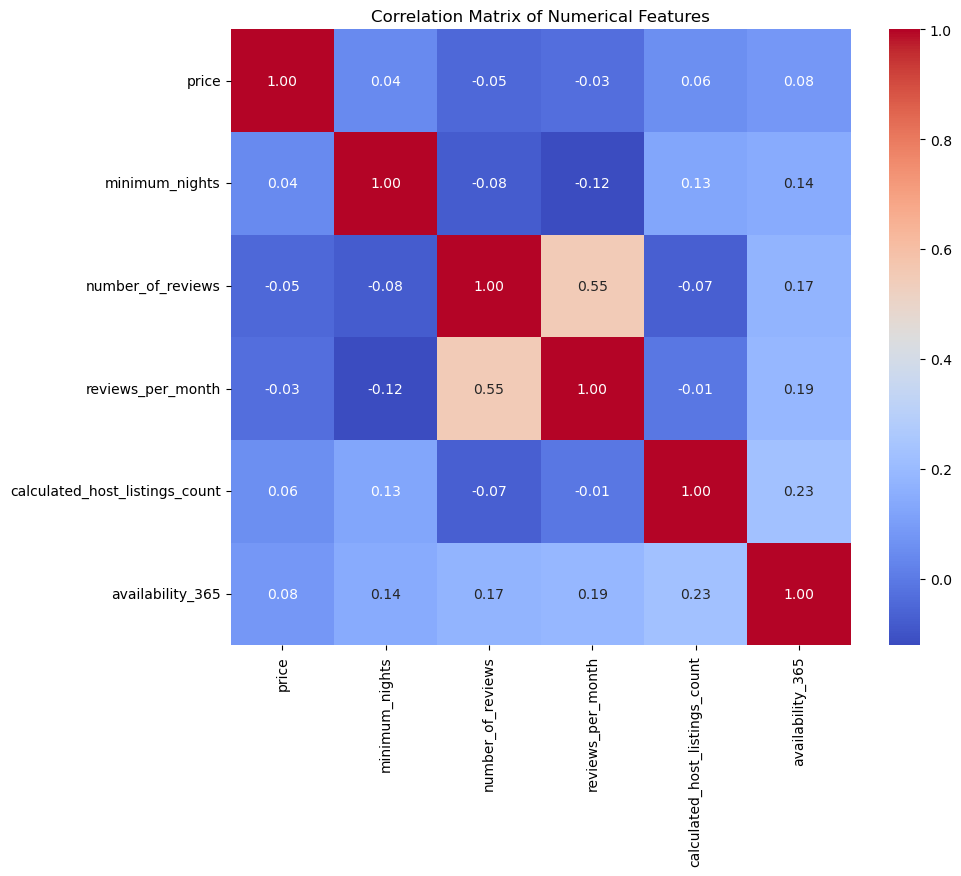

In [36]:
plt.figure(figsize=(10,8))

corr = df[['price',
           'minimum_nights',
           'number_of_reviews',
           'reviews_per_month',
           'calculated_host_listings_count',
           'availability_365']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()


### Interpretation

Identify positive and negative correlations.  
Check whether any predictors are highly correlated (|r| > 0.80), which may indicate multicollinearity.  
Note that correlation measures only linear association and does not imply causation.  

#### Business Insight

Price is influenced by multiple variables rather than a single dominant numerical feature, highlighting the need for multivariate modeling.

#### OLS Perspective

Correlation is an initial diagnostic only.  
Before fitting OLS, multicollinearity will be formally assessed using the Variance Inflation Factor (VIF).

#### Assessment	Status

Multicollinearity Check	Preliminary
VIF Required-	Yes
Proceed to OLS	After diagnostics

###  Conclusion of Bivariate Analysis

Room Type and Neighbourhood Group are expected to be the strongest categorical predictors of Airbnb prices.  
The numerical variables (minimum_nights, number_of_reviews, reviews_per_month, and availability_365) should be evaluated based on the fitted regression line, correlation coefficients, and later their OLS p-values rather than visual inspection alone.  
The correlation matrix provides an initial assessment of relationships among numerical variables.   
A formal VIF analysis will be performed before OLS regression to ensure that multicollinearity is not a concern.  
At the end of the bivariate stage, no feature should be dropped.   
Feature selection will be based on statistical evidence from the OLS model and diagnostic tests, not solely on EDA visuals.

# Multivariate Analysis

Objective: Analyze the combined relationship among multiple variables, identify interaction patterns, detect multicollinearity, and assess suitability for OLS Regression.

# Correlation Heatmap


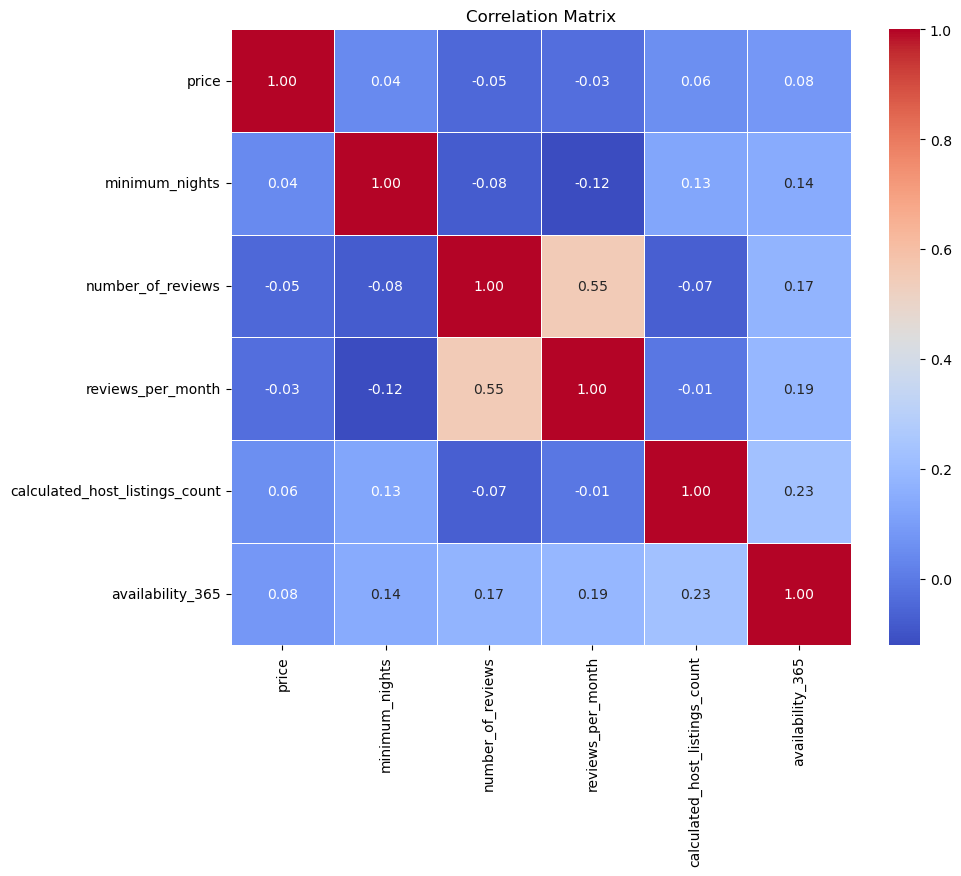

In [37]:
plt.figure(figsize=(10,8))

corr = df[['price',
           'minimum_nights',
           'number_of_reviews',
           'reviews_per_month',
           'calculated_host_listings_count',
           'availability_365']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()


### Interpretation

Evaluate the strength and direction of relationships among numerical variables.  
Features with |r| > 0.80 should be examined for multicollinearity.  
Correlation only measures linear association and does not imply causation.

#### Business Insight

The pricing mechanism is influenced by multiple numerical factors rather than a single dominant variable, indicating that price prediction requires a multivariate approach.

#### OLS Perspective

This is the first screening step for multicollinearity.   
Variables showing very high correlation should be further evaluated using Variance Inflation Factor (VIF) before model fitting.

#### Assessment	Status

Multicollinearity Screening	Completed
VIF Required-	Yes
Keep Variables-	Yes


# Pair Plot (Numerical Variables)


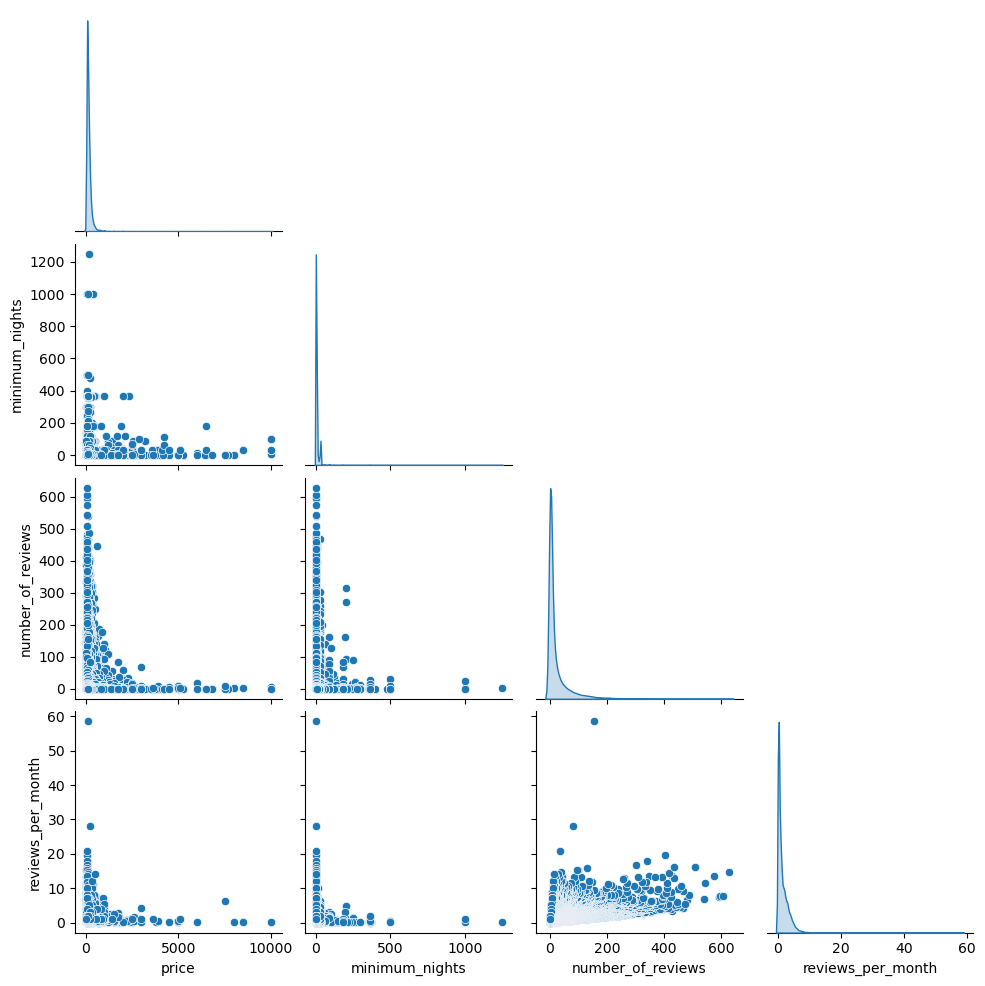

In [38]:
selected = df[['price',
               'minimum_nights',
               'number_of_reviews',
               'reviews_per_month']]

sns.pairplot(selected,
             diag_kind='kde',
             corner=True)

plt.show()


### Interpretation

Observe pairwise relationships among the selected numerical variables.  
Identify linear or non-linear patterns.  
Detect clusters and extreme observations.  
Compare individual variable distributions on the diagonal.

#### Business Insight

The pair plot provides a comprehensive overview of how numerical variables jointly behave, helping identify variables that may contribute to pricing decisions.

#### OLS Perspective

Pair plots help assess whether approximate linear relationships exist between predictors and the target variable.
Strong non-linear patterns may require transformation during preprocessing.

#### Assessment	Status

Pairwise Relationship-	Evaluated
Non-linearity Check-	Completed
Proceed to OLS-	Yes


# Price by Room Type Across Neighbourhood Groups


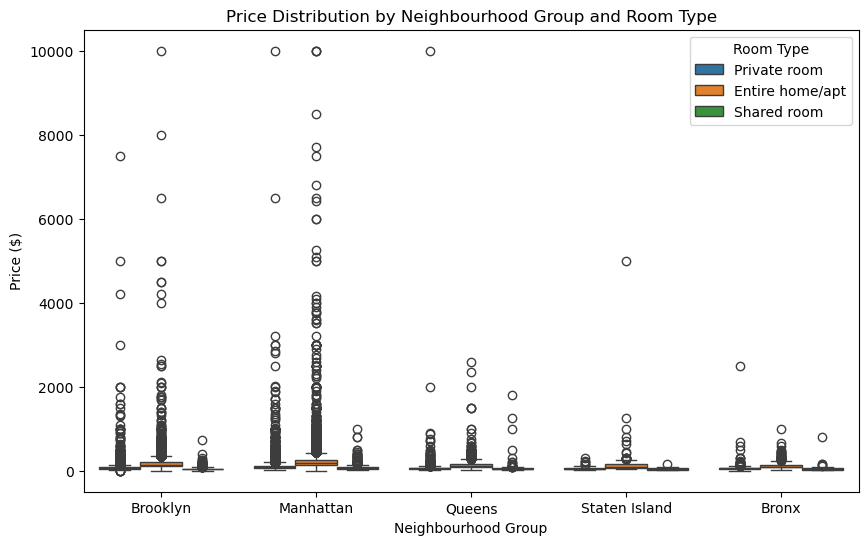

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    hue='room_type'
)

plt.title("Price Distribution by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.legend(title="Room Type")
plt.show()


### Interpretation

Compare prices across neighbourhood groups while simultaneously considering room type.  
Identify whether the effect of room type changes across different locations.  
Observe variability and outliers within each combination.

#### Business Insight

Pricing is influenced jointly by location and room type, demonstrating that these factors interact in determining listing value.

#### OLS Perspective

Indicates the possibility of interaction effects between categorical variables.  
Interaction terms may be explored later if they improve model performance.

#### Assessment	Status

Interaction Effect-	Explored
Keep Variables-	Yes


# Scatter Plot (Latitude × Longitude Colored by Price)


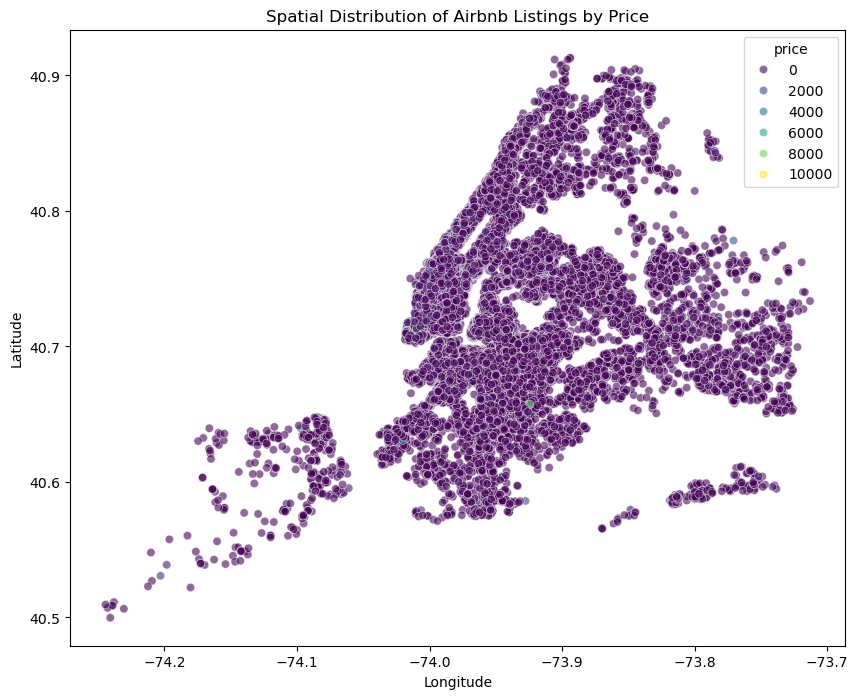

In [40]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis',
    alpha=0.6
)

plt.title("Spatial Distribution of Airbnb Listings by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Interpretation

Visualize the geographic distribution of listings.  
Identify whether higher-priced properties cluster in particular locations.  
Detect regional concentration patterns.

#### Business Insight

Location is a major determinant of Airbnb pricing, and geographical clustering indicates that neighborhood characteristics influence property value.

#### OLS Perspective

Latitude and longitude may capture spatial variation not fully represented by neighbourhood variables.  
These variables should be evaluated alongside neighbourhood-based predictors to avoid redundant information.

#### Assessment	Status

Spatial Pattern-	Evaluated
Keep Coordinates-	Yes (evaluate later)


### Conclusion of Multivariate Analysis

The correlation matrix provides an initial assessment of relationships among numerical predictors and helps identify potential multicollinearity.  
The pair plot offers a comprehensive overview of pairwise relationships, distributions, and possible non-linear trends.   
The combined analysis of Neighbourhood Group and Room Type demonstrates that Airbnb prices are jointly influenced by both location and accommodation type.    
The spatial distribution plot highlights the importance of geographic location in pricing and suggests that latitude and longitude may contribute additional explanatory power.   
At this stage, no variables are removed.  
Feature selection will be based on VIF analysis, OLS p-values, and diagnostic tests rather than visual inspection alone.


# Missing Value Treatment

###  Check Missing Values


In [41]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing (%)': round((df.isnull().sum()/len(df))*100,2)
})

missing = missing[missing['Missing Values'] > 0]
missing.sort_values(by='Missing Values', ascending=False)

,Missing Values,Missing (%)
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


###  Missing Value Analysis

#### 1. reviews_per_month

#### Observation
Missing Values: 10,052 (20.56%)

#### Interpretation

Listings with missing reviews_per_month generally have no recorded reviews.   
Therefore, these missing values are structural missing values, not random missing values.

#### Business Insight

A listing that has never been reviewed naturally has 0 reviews per month.

#### Decision

Fill missing values with 0.


In [42]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

#### OLS Perspective

Filling with 0 preserves the business meaning of the variable.  
This avoids unnecessary row deletion and retains valuable observations for regression analysis.

#### 2. Last Review

#### Observation
Missing Values: 10,052 (20.56%)
                        
#### Interpretation

Listings without reviews do not have a recorded review date.

#### Business Insight

Since this feature is a date variable and will not be directly used in the OLS regression model, imputing dates would
not add meaningful information.

#### Decision

Drop the column.

df.drop(columns=['last_review'], inplace=True)


#### OLS Perspective

The variable does not directly contribute to predicting price.  
Removing it simplifies the model and avoids unnecessary preprocessing.

### 3. Host Name

#### Observation
Missing Values: 21 (0.04%)


#### Interpretation

The number of missing values is negligible.

#### Business Insight

The host's name is an identifier rather than a predictive feature.

#### Decision

Drop the column.


In [43]:
df.drop(columns=['host_name'], inplace=True)


#### OLS Perspective

Host names have no quantitative predictive value.  
Removing this identifier reduces unnecessary dimensionality.

### 4. Listing Name

#### Observation
Missing Values: 16 (0.03%)

#### Interpretation

The listing name is descriptive text rather than a numerical or categorical predictor for the planned OLS model.

#### Business Insight

The model focuses on structured variables such as location, room type, reviews, and availability rather than free-text titles.

####  Decision

Drop the column.


In [44]:
df.drop(columns=['name'], inplace=True)


#### OLS Perspective

Text features are outside the scope of the current regression model.  
Removing the variable simplifies preprocessing.

# Verify Missing Values

In [45]:
df.isnull().sum()

id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [46]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing (%)': round((df.isnull().sum()/len(df))*100,2)
})

missing[missing['Missing Values'] > 0]

,Missing Values,Missing (%)
last_review,10052,20.56


| Variable          | Missing % | Treatment   | Reason                                 |
| ----------------- | --------: | ----------- | -------------------------------------- |
| reviews_per_month |    20.56% | Fill with 0 | Structural missing values (no reviews) |
| last_review       |    20.56% | Drop        | Date feature not required for OLS      |
| host_name         |     0.04% | Drop        | Identifier, not predictive             |
| name              |     0.03% | Drop        | Free-text field, not used in OLS       |


## OLS Perspective

Missing values were handled using business-driven decisions rather than applying a single imputation method to all variables.  
reviews_per_month was imputed with 0 because missing values represent listings with no review activity.  
Textual and identifier variables (name, host_name) and the date field (last_review) were removed since they do not provide meaningful predictive information for OLS regression.  
This approach preserves the maximum number of observations while ensuring that only relevant and model-ready variables remain for subsequent preprocessing and regression analysis.


#  Outlier Analysis & Treatment

### Objective

Identify outliers in numerical features.  

Determine whether they are genuine observations or data errors.  
Decide whether to retain, transform, cap (winsorize), or remove them based on statistical evidence and business context.

#### 1. Select Numerical Features

In [47]:
num_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

#### 2. Boxplots (Initial Detection)

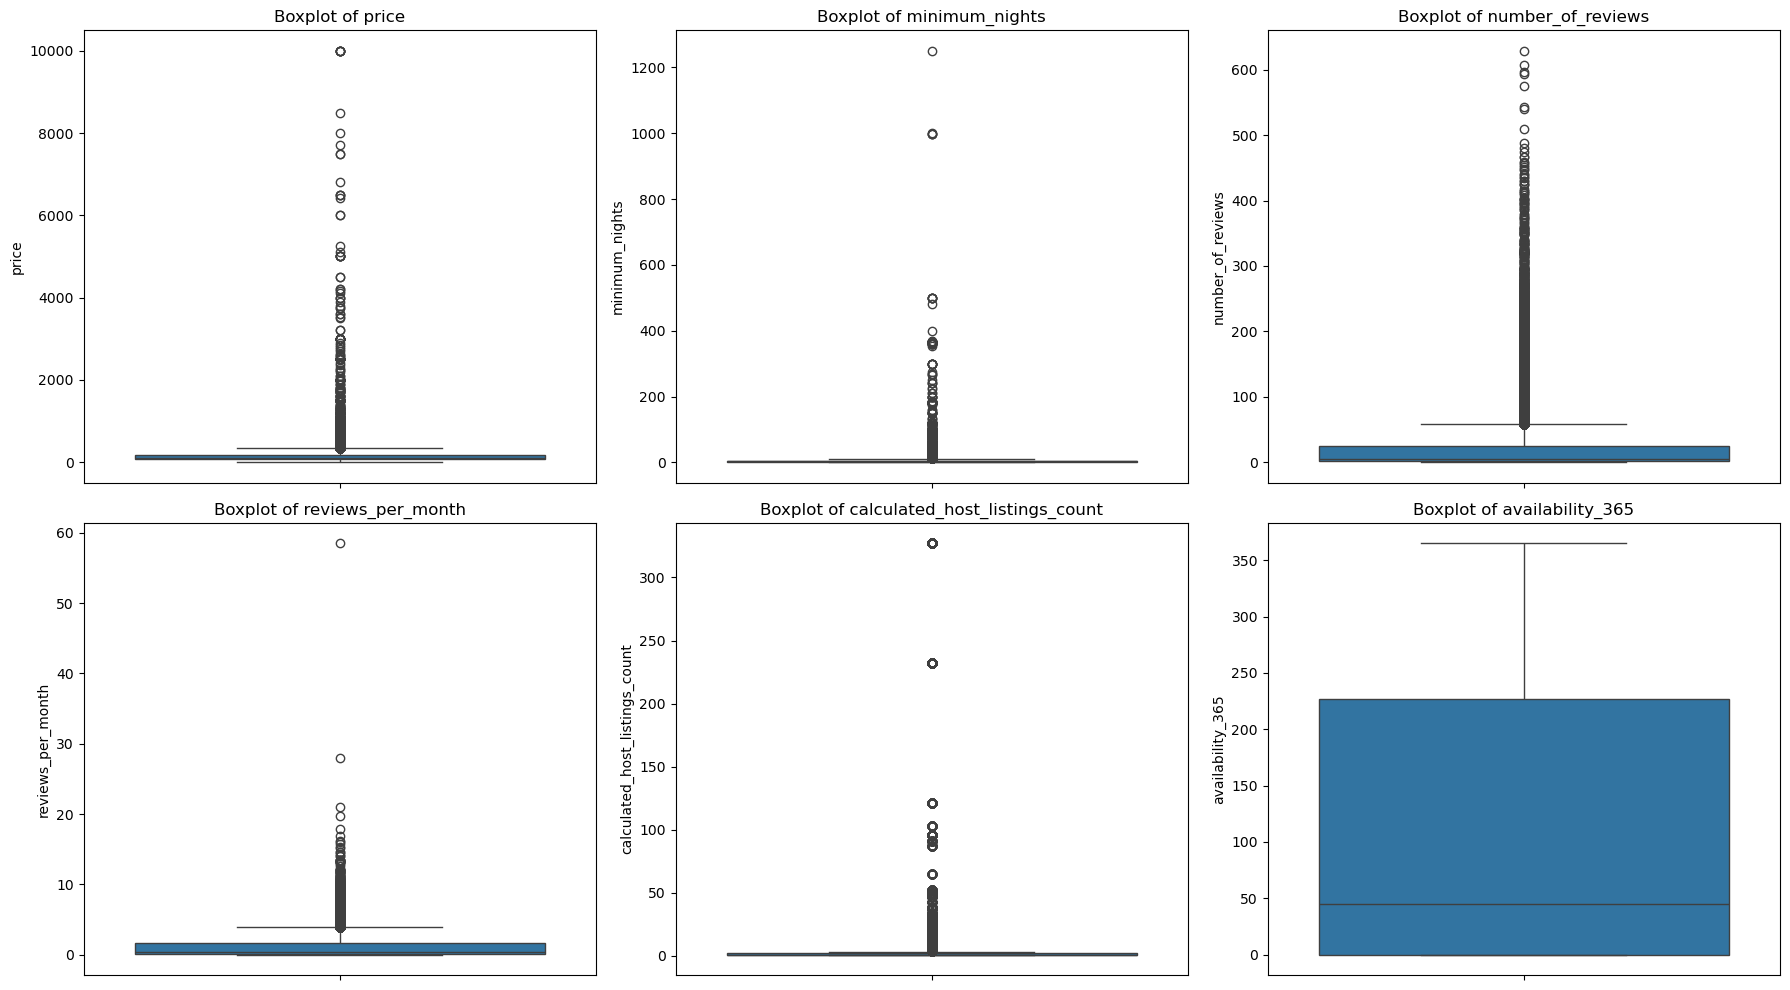

In [48]:
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Interpretation

Boxplots provide an initial visual assessment of extreme observations.  
Values beyond 1.5 × IQR appear as potential outliers.  
These observations are potential outliers and require statistical verification before any treatment.

#### 3. IQR-Based Outlier Detection

In [49]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": round(lower,2),
        "Upper Bound": round(upper,2),
        "Outliers": outliers,
        "Outlier %": round(outliers/len(df)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Lower Bound,Upper Bound,Outliers,Outlier %
0,price,-90.00,334.00,2972,6.08
1,minimum_nights,-5.00,11.00,6607,13.51
2,number_of_reviews,-33.50,58.50,6021,12.31
3,reviews_per_month,-2.27,3.89,3312,6.77
4,calculated_host_listings_count,-0.50,3.50,7081,14.48
5,availability_365,-340.50,567.50,0,0.00


# Feature-wise Interpretation

#### A. Price

#### Interpretation 

High-priced listings are expected in Airbnb data.  
Premium and luxury properties naturally create extreme values.  
The maximum price (10,000) is substantially higher than the median (106), indicating a right-skewed distribution.

#### Business Insight

Luxury listings represent a genuine segment of the market and should not automatically be treated as erroneous data.

#### OLS Perspective

Retain initially.
If residual diagnostics later indicate non-normality or heteroscedasticity, consider a log transformation of price.

#### B. Minimum Nights

#### Interpretation

A few listings require exceptionally long minimum stays (up to 1250 nights).  
These may correspond to long-term rental policies rather than errors.  

#### Business Insight

Long-term rental listings reflect legitimate host strategies.

#### OLS Perspective

Retain for now.  
Reassess if these values disproportionately influence the regression model.


#### C. Number of Reviews

#### Interpretation

Listings with a very high number of reviews are highly popular properties.  
These observations represent genuine business behavior

#### Business Insight

High review counts indicate customer engagement and listing popularity.

#### OLS Perspective
Retain.  
Influence diagnostics (e.g., Cook's Distance) will identify whether they unduly affect the model.

#### D. Reviews per Month

#### Interpretation

High review frequency reflects listings with frequent bookings.  
These values are plausible in an active marketplace.

#### Business Insight

Review frequency captures booking intensity and should be preserved.

#### OLS Perspective
Retain.
Consider transformation only if model diagnostics suggest severe skewness.

#### E. Calculated Host Listings Count

#### Interpretation

Some hosts manage a very large number of listings (up to 327).  
These are likely professional property managers rather than data errors.

#### Business Insight

Commercial hosts play an important role in the Airbnb ecosystem.

#### OLS Perspective

Retain.  
Evaluate influence using regression diagnostics.

#### F. Availability 365

#### Interpretation

Values naturally range between 0 and 365.  
Observations at the boundaries are valid and expected.

#### Business Insight

Availability reflects host strategy and occupancy, not erroneous measurements.

#### OLS Perspective

No outlier treatment required.

###  Conclusion

#### Key Findings

Outliers were identified in several numerical variables using the IQR method.  
Most extreme observations correspond to legitimate business scenarios (luxury listings, professional hosts, highly reviewed properties, long-term rentals) rather than data quality issues.  
Therefore, these observations are considered valid business outliers.  

#### OLS Perspective

Outliers are not removed at this stage.  
Their impact will be evaluated through:  
Residual diagnostics  
Cook's Distance  
Leverage analysis   
Studentized residuals  
If they are found to unduly influence the model, an appropriate treatment (e.g., log transformation or winsorization) will be considered based on statistical evidence rather than visual inspection alone.

| Feature                        | Outliers Detected  | Treatment                                     |
| ------------------------------ | ------------------ | --------------------------------------------- |
| Price                          | Yes                | Keep (consider log transform later if needed) |
| Minimum Nights                 | Yes                | Keep                                          |
| Number of Reviews              | Yes                | Keep                                          |
| Reviews per Month              | Yes                | Keep                                          |
| Calculated Host Listings Count | Yes                | Keep                                          |
| Availability 365               | No practical issue | Keep                                          |


# Feature Selection & Data Preparation

#### 1 Drop Unnecessary Columns

Ye columns regression model mein use nahi honge.

In [50]:
cols_to_drop = ['id', 'host_id', 'name', 'host_name', 'last_review']

df.drop(columns=cols_to_drop,errors='ignore', inplace=True)


| Feature     | Reason                                  |
| ----------- | --------------------------------------- |
| id          | Unique identifier                       |
| host_id     | Unique identifier                       |
| name        | Free-text, not useful for OLS           |
| host_name   | Identifier                              |
| last_review | Date variable not used in current model |


### OLS Perspective

These variables do not explain the variation in price and may unnecessarily increase model complexity.

### Separate Features and Target

In [51]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [52]:
X = df.drop('price', axis=1)
y = df['price']


In [53]:
print(df.columns)
print(X.columns)
print(y.head())

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')
Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')
0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64


#### Encode Categorical Variables

X = pd.get_dummies(
    X,
    columns=[
        'room_type',
        'neighbourhood_group',
        'neighbourhood'
    ],
    drop_first=True
)

### OLS Perspective

One-Hot Encoding converts categorical variables into binary indicators.  
drop_first=True avoids the Dummy Variable Trap and helps prevent perfect multicollinearity.  

####  Verify Data Types


In [54]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


# Train-Test Split


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Report
Training Data: 80%  
Testing Data: 20%  
Random State: 42  

#### OLS Perspective

The model will be trained on 80% of the data and evaluated on the remaining 20% to assess generalization performance.

#### Conclusion

At the end of this step:

Dataset contains only relevant predictors.
Missing values have been handled.
Outliers have been assessed.
Categorical variables have been encoded.
Target and predictor variables have been separated.
Data has been split into training and testing sets.
The dataset is now ready for OLS Regression Modeling.

# OLS Regression Model

In [56]:
import statsmodels.api as sm

#### Define Target and Features

In [57]:
X = df.drop('price', axis=1)
y = df['price']

#### One-Hot Encode Categorical Variables

In [58]:
X = pd.get_dummies(
    X,
    columns=[
        'neighbourhood_group',
        'neighbourhood',
        'room_type'
    ],
    drop_first=True,
    dtype=int
)

In [59]:
X.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,1,9,0.21,6,365,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,40.75362,-73.98377,1,45,0.38,2,355,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,40.80902,-73.94190,3,0,0.00,1,365,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,40.68514,-73.95976,1,270,4.64,1,194,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,40.79851,-73.94399,10,9,0.10,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


#### Train-Test Split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [61]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39116, 233)
(9779, 233)
(39116,)
(9779,)


####  Add Constant (Intercept)

In [62]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [63]:
X_train.head()

,const,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
32645,1.0,40.71577,-73.95530,3,11,0.87,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
23615,1.0,40.84917,-73.94048,2,2,0.16,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
31183,1.0,40.68993,-73.95947,2,0,0.00,2,0,1,0,...,0,0,0,0,0,0,0,0,1,0
29260,1.0,40.68427,-73.93118,3,87,4.91,1,267,1,0,...,0,0,0,0,0,0,0,0,0,0
7275,1.0,40.74705,-73.89564,5,13,0.25,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0


#### OLS Perspective

The constant represents the intercept (β₀) of the regression equation. Without it, the regression line is forced to pass through the origin, which is generally inappropriate for real-world data.

####  Fit the OLS Model

In [64]:
ols_model = sm.OLS(y_train, X_train).fit()

# Final model (display summary)

In [65]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     21.70
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:43:56   Log-Likelihood:            -2.6867e+05
No. Observations:               39116   AIC:                         5.378e+05
Df Residuals:                   38887   BIC:                         5.398e+05
Df Model:                         228                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

## Report

#### Objective

An Ordinary Least Squares (OLS) regression model was developed to quantify the relationship between Airbnb listing price (dependent variable) and the selected explanatory variables.

#### Model Specification
Dependent Variable: price  
Independent Variables:  
latitude  
longitude  
minimum_nights  
number_of_reviews  
reviews_per_month  
calculated_host_listings_count  
availability_365  
neighbourhood_group (dummy variables)  
neighbourhood (dummy variables)  
room_type (dummy variables)  

#### OLS Perspective

The model estimates regression coefficients by minimizing the Residual Sum of Squares (RSS). Each coefficient represents the expected change in listing price associated with a one-unit change in the corresponding predictor, holding all other variables constant.

## Summary Interpretation Report

The Ordinary Least Squares (OLS) regression model was successfully fitted to estimate Airbnb listing prices using the selected explanatory variables.  
The model summary provides statistical evidence regarding model fit, predictor significance, and diagnostic statistics.

## OLS Regression Model Report

#### 1. Model Summary

Model: Ordinary Least Squares (OLS)  
Dependent Variable: Price   
Observations: 39,116  
R-squared: 0.113  
Adjusted R-squared: 0.108  
F-statistic: 21.70  
Prob (F-statistic): 0.000

#### Interpretation

Model statistically significant hai kyunki Prob(F-statistic) = 0.000 (<0.05).  
Model price ki lagbhag 11.3% variation explain karta hai (R² = 0.113).  
Iska matlab hai ki dataset me aur bhi aise factors hain jo price ko affect karte hain aur model me include nahi hain.

#### 2. Significant Variables (p-value < 0.05)

Significant variables me shamil hain:

Longitude  
Number of Reviews  
Reviews per Month  
Calculated Host Listings Count  
Availability 365  
Room Type (Private Room)  
Room Type (Shared Room)  
Kuch Neighbourhood categories

Ye variables price par statistically significant effect dikhate hain.

#### 3. Non-Significant Variables

Kuch variables jaise:

Latitude  
Minimum Nights  
Neighbourhood Group (Brooklyn, Manhattan, Queens)  

inka p-value > 0.05 hai.

Iska matlab is model ke hisaab se ye variables statistically significant nahi hain.

#### 4. Model Diagnostics

Durbin-Watson = 1.997  
Value 2 ke bahut close hai.  
Iska matlab residuals me autocorrelation ki problem nahi hai.  
Omnibus & Jarque-Bera Test  
Prob = 0.000

Residuals normal distribution follow nahi karte.  

Skewness = 21.214

Residuals bahut zyada positively skewed hain.   

Kurtosis = 673.554

Residuals me bahut heavy tails (outliers) hain.  

Condition Number = 5.46 × 10¹⁸  

Ye value bahut high hai.  

Isse pata chalta hai ki model me strong multicollinearity ya dummy variable dependency ki problem ho sakti hai.

#### 5. Overall Conclusion

 Model statistically significant hai.  
 Important predictors identify hue hain.  
 R² sirf 11.3% hai, isliye predictive power low hai.  
 Residuals normal nahi hain.  
 Strong multicollinearity present hai.  
 Model ko improve karne ke liye VIF analysis, feature selection aur multicollinearity treatment ki zarurat hai.


In [66]:
print(X_train.shape)


(39116, 234)


In [67]:
print(X_train.columns)

Index(['const', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'neighbourhood_group_Brooklyn',
       'neighbourhood_group_Manhattan',
       ...
       'neighbourhood_Williamsbridge', 'neighbourhood_Williamsburg',
       'neighbourhood_Willowbrook', 'neighbourhood_Windsor Terrace',
       'neighbourhood_Woodhaven', 'neighbourhood_Woodlawn',
       'neighbourhood_Woodrow', 'neighbourhood_Woodside',
       'room_type_Private room', 'room_type_Shared room'],
      dtype='object', length=234)


In [68]:
print(X_train.head())

       const  latitude  longitude  minimum_nights  number_of_reviews  \
32645    1.0  40.71577  -73.95530               3                 11   
23615    1.0  40.84917  -73.94048               2                  2   
31183    1.0  40.68993  -73.95947               2                  0   
29260    1.0  40.68427  -73.93118               3                 87   
7275     1.0  40.74705  -73.89564               5                 13   

       reviews_per_month  calculated_host_listings_count  availability_365  \
32645               0.87                               1                 1   
23615               0.16                               1                 0   
31183               0.00                               2                 0   
29260               4.91                               1               267   
7275                0.25                               1                 0   

       neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  ...  \
32645                  

In [69]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39116, 234)
(9779, 234)
(39116,)
(9779,)


In [70]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [71]:
X_train

,const,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
32645,1.0,40.71577,-73.95530,3,11,0.87,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
23615,1.0,40.84917,-73.94048,2,2,0.16,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
31183,1.0,40.68993,-73.95947,2,0,0.00,2,0,1,0,...,0,0,0,0,0,0,0,0,1,0
29260,1.0,40.68427,-73.93118,3,87,4.91,1,267,1,0,...,0,0,0,0,0,0,0,0,0,0
7275,1.0,40.74705,-73.89564,5,13,0.25,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.0,40.84650,-73.94319,1,0,0.00,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
44732,1.0,40.73957,-74.00082,2,4,1.90,1,76,0,1,...,0,0,0,0,0,0,0,0,1,0
38158,1.0,40.78318,-73.97372,30,1,0.34,5,261,0,1,...,0,0,0,0,0,0,0,0,0,0
860,1.0,40.77508,-73.97990,2,11,0.13,1,2,0,1,...,0,0,0,0,0,0,0,0,0,0


In [72]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


#  Multicollinearity

In [73]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39116 entries, 32645 to 15795
Columns: 234 entries, const to room_type_Shared room
dtypes: float64(4), int64(230)
memory usage: 70.1 MB


In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_small = X_train.iloc[:, :10]

vif = pd.DataFrame()
vif["Feature"] = X_small.columns
vif["VIF"] = [
    variance_inflation_factor(X_small.values, i)
    for i in range(X_small.shape[1])
]

print(vif)

                          Feature           VIF
0                           const  7.537319e+06
1                        latitude  2.130075e+00
2                       longitude  1.872724e+00
3                  minimum_nights  1.054449e+00
4               number_of_reviews  1.553078e+00
5               reviews_per_month  1.576271e+00
6  calculated_host_listings_count  1.111265e+00
7                availability_365  1.149373e+00
8    neighbourhood_group_Brooklyn  3.331589e+00
9   neighbourhood_group_Manhattan  4.285490e+00


 const ko ignore karte hain. Constant ka VIF dekhte hi nahi hain. Ye normal hai.

Baaki continuous variables ka VIF 5 se bhi kam hai, matlab ye sab theek hain. 

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF DataFrame
vif = pd.DataFrame()

# Column names
vif["Feature"] = X_train.columns

# VIF calculation
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

# Round values
vif["VIF"] = vif["VIF"].round(2)

# Highest VIF first
vif = vif.sort_values(by="VIF", ascending=False)

vif.head(20)


,Feature,VIF
116,neighbourhood_Jamaica,inf
176,neighbourhood_Richmondtown,inf
112,neighbourhood_Huguenot,inf
198,neighbourhood_Stapleton,inf
114,neighbourhood_Inwood,inf
115,neighbourhood_Jackson Heights,inf
197,neighbourhood_St. George,inf
117,neighbourhood_Jamaica Estates,inf
118,neighbourhood_Jamaica Hills,inf
119,neighbourhood_Kensington,inf


In [76]:
Ye normal nahi hai. Iska matlab hai perfect multicollinearity.
Design Matrix = Model me use hone wale saare independent variables (X).

Tumhare case me ye hain:

latitude
longitude
minimum_nights
room_type dummies
neighbourhood dummies
etc.

Ye sab milkar Design Matrix banate hain.

Singular ka matlab kya hai?

Singular ka matlab hai:

Model ke kuch columns independent nahi hain. Kuch columns ek dusre se exact ya almost exact relation me hain.

Yaani model confuse ho gaya hai ki kis feature ka actual effect kitna hai.


SyntaxError: invalid syntax (3568288530.py, line 1)

In [ ]:
Yahan Age aur DOB se nikli Age bilkul same information de rahe hain.

Model sochega:

"Price kis wajah se badh rahi hai? Age ki wajah se ya DOB wali Age ki wajah se?"

Wo decide hi nahi kar pata.

Isliye matrix singular ho jati hai.

Tumhare dataset me kyu hua?

Tumhare OLS summary me tha:

Condition Number = 5.46 × 10¹⁸ (bahut high)
Smallest Eigenvalue bahut chhoti
VIF me bahut saare inf

Ye sab milkar batate hain ki perfect multicollinearity hai.

Sabse likely wajah:

Bahut saare neighbourhood dummy variables.
Kuch dummy columns me sirf 0 hain ya bahut kam observations hain.
Kuch dummy columns ek dusre par depend kar rahe hain.
Iska nuksan kya hai?
❌ Coefficients unreliable ho jate hain.
❌ Standard errors badh jate hain.
❌ P-values galat ho sakti hain.
❌ Model feature ka actual contribution nahi bata pata.
Iska solution
High VIF wale features identify karo.
Zero variance (sirf 0 ya sirf 1 wale) columns hatao.
Rare dummy categories ko merge ya remove karo.
Phir OLS model dubara fit karo.
Report me professional conclusion

Tum report me likh sakti ho:

"The OLS summary indicated that the design matrix is singular, suggesting perfect multicollinearity among some predictor variables. This was further confirmed by infinite VIF values for several dummy variables. Therefore, multicollinearity diagnostics and feature reduction were required before finalizing the regression model."

In [ ]:
X_train.nunique().sort_values().head(20)

In [ ]:
X_train.columns[X_train.nunique()==1]

In [ ]:
Matlab neighbourhood_Woodrow training data me sirf 1 baar hai.

Isliye:

us column me sirf ek hi row me 1 hai
baaki sab rows me 0
Model uska effect estimate nahi kar pata.
Isi wajah se Design Matrix is Singular aur VIF = Infinity (∞) aa raha hai.

In [77]:
rare_cols = X_train.columns[X_train.sum() <= 1]

print(len(rare_cols))
print(rare_cols)

11
Index(['longitude', 'neighbourhood_Fort Wadsworth',
       'neighbourhood_Howland Hook', 'neighbourhood_Lighthouse Hill',
       'neighbourhood_New Dorp', 'neighbourhood_Richmondtown',
       'neighbourhood_Rossville', 'neighbourhood_West Farms',
       'neighbourhood_Westerleigh', 'neighbourhood_Willowbrook',
       'neighbourhood_Woodrow'],
      dtype='object')


In [78]:
ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     21.70
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:14:14   Log-Likelihood:            -2.6867e+05
No. Observations:               39116   AIC:                         5.378e+05
Df Residuals:                   38887   BIC:                         5.398e+05
Df Model:                         228                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_small = X_train.iloc[:, :10]

vif = pd.DataFrame()
vif["Feature"] = X_small.columns
vif["VIF"] = [
    variance_inflation_factor(X_small.values, i)
    for i in range(X_small.shape[1])
]

print(vif)

                          Feature           VIF
0                           const  7.537319e+06
1                        latitude  2.130075e+00
2                       longitude  1.872724e+00
3                  minimum_nights  1.054449e+00
4               number_of_reviews  1.553078e+00
5               reviews_per_month  1.576271e+00
6  calculated_host_listings_count  1.111265e+00
7                availability_365  1.149373e+00
8    neighbourhood_group_Brooklyn  3.331589e+00
9   neighbourhood_group_Manhattan  4.285490e+00


In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif["VIF"] = vif["VIF"].round(2)
vif = vif.sort_values(by="VIF", ascending=False)

vif.head(20)

,Feature,VIF
116,neighbourhood_Jamaica,inf
176,neighbourhood_Richmondtown,inf
112,neighbourhood_Huguenot,inf
198,neighbourhood_Stapleton,inf
114,neighbourhood_Inwood,inf
115,neighbourhood_Jackson Heights,inf
197,neighbourhood_St. George,inf
117,neighbourhood_Jamaica Estates,inf
118,neighbourhood_Jamaica Hills,inf
119,neighbourhood_Kensington,inf


In [81]:
vif.head(20)

,Feature,VIF
116,neighbourhood_Jamaica,inf
176,neighbourhood_Richmondtown,inf
112,neighbourhood_Huguenot,inf
198,neighbourhood_Stapleton,inf
114,neighbourhood_Inwood,inf
115,neighbourhood_Jackson Heights,inf
197,neighbourhood_St. George,inf
117,neighbourhood_Jamaica Estates,inf
118,neighbourhood_Jamaica Hills,inf
119,neighbourhood_Kensington,inf


In [82]:
inf_cols = vif[vif["VIF"] == float("inf")]["Feature"]

print(inf_cols)

116          neighbourhood_Jamaica
176     neighbourhood_Richmondtown
112         neighbourhood_Huguenot
198        neighbourhood_Stapleton
114           neighbourhood_Inwood
                  ...             
60      neighbourhood_Coney Island
61            neighbourhood_Corona
62     neighbourhood_Crown Heights
63     neighbourhood_Cypress Hills
175    neighbourhood_Richmond Hill
Name: Feature, Length: 176, dtype: object


In [87]:
X = df.drop(['price', 'neighbourhood_group'], axis=1)

In [94]:
X = df.drop("price", axis=1)
y = df["price"]

X = pd.get_dummies(
    X,
    columns=["neighbourhood_group", "neighbourhood", "room_type"],
    drop_first=True,
    dtype=int
)

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [96]:
import statsmodels.api as sm

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [104]:
ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     21.70
Date:                Wed, 05 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:51:32   Log-Likelihood:            -2.6867e+05
No. Observations:               39116   AIC:                         5.378e+05
Df Residuals:                   38887   BIC:                         5.398e+05
Df Model:                         228                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [100]:
print(X_train.shape)

(39116, 234)


In [101]:
print(X_train.head())
print(X_train.columns[:10])

       const  latitude  longitude  minimum_nights  number_of_reviews  \
32645    1.0  40.71577  -73.95530               3                 11   
23615    1.0  40.84917  -73.94048               2                  2   
31183    1.0  40.68993  -73.95947               2                  0   
29260    1.0  40.68427  -73.93118               3                 87   
7275     1.0  40.74705  -73.89564               5                 13   

       reviews_per_month  calculated_host_listings_count  availability_365  \
32645               0.87                               1                 1   
23615               0.16                               1                 0   
31183               0.00                               2                 0   
29260               4.91                               1               267   
7275                0.25                               1                 0   

       neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  ...  \
32645                  

In [102]:
X_train.dtypes.value_counts()

int64      230
float64      4
Name: count, dtype: int64

In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)
print(vif.head(20))

                               Feature  VIF
116              neighbourhood_Jamaica  inf
176         neighbourhood_Richmondtown  inf
112             neighbourhood_Huguenot  inf
198            neighbourhood_Stapleton  inf
114               neighbourhood_Inwood  inf
115      neighbourhood_Jackson Heights  inf
197           neighbourhood_St. George  inf
117      neighbourhood_Jamaica Estates  inf
118        neighbourhood_Jamaica Hills  inf
119           neighbourhood_Kensington  inf
120          neighbourhood_Kew Gardens  inf
121    neighbourhood_Kew Gardens Hills  inf
196           neighbourhood_St. Albans  inf
123             neighbourhood_Kips Bay  inf
124            neighbourhood_Laurelton  inf
125      neighbourhood_Lighthouse Hill  inf
126         neighbourhood_Little Italy  inf
127          neighbourhood_Little Neck  inf
128     neighbourhood_Long Island City  inf
194  neighbourhood_Springfield Gardens  inf


In [108]:
X_train.columns.tolist()

['const',
 'latitude',
 'longitude',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'neighbourhood_group_Brooklyn',
 'neighbourhood_group_Manhattan',
 'neighbourhood_group_Queens',
 'neighbourhood_group_Staten Island',
 'neighbourhood_Arden Heights',
 'neighbourhood_Arrochar',
 'neighbourhood_Arverne',
 'neighbourhood_Astoria',
 'neighbourhood_Bath Beach',
 'neighbourhood_Battery Park City',
 'neighbourhood_Bay Ridge',
 'neighbourhood_Bay Terrace',
 'neighbourhood_Bay Terrace, Staten Island',
 'neighbourhood_Baychester',
 'neighbourhood_Bayside',
 'neighbourhood_Bayswater',
 'neighbourhood_Bedford-Stuyvesant',
 'neighbourhood_Belle Harbor',
 'neighbourhood_Bellerose',
 'neighbourhood_Belmont',
 'neighbourhood_Bensonhurst',
 'neighbourhood_Bergen Beach',
 'neighbourhood_Boerum Hill',
 'neighbourhood_Borough Park',
 'neighbourhood_Breezy Point',
 'neighbourhood_Briarwood',
 'neighbourhood_Brighton Beach',
 'neighbou

In [109]:
print(len(X_train.columns))

234


In [111]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Fort Wadsworth           1
Richmondtown             1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64